<a href="https://colab.research.google.com/github/Kottckema/Solar/blob/main/Solar_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


=== SMARD-Daten-Download für 01.2026 - 06.2026 ===

  Lade Index für PV-Einspeisung (MWh/h) ...

  4029 Stundenwerte für PV-Einspeisung (MWh/h) geladen.
  Lade Index für Day-Ahead-Preis (€/MWh) ...

  4054 Stundenwerte für Day-Ahead-Preis (€/MWh) geladen.

=== Zusammenfassung ===
Zeitraum:              2026-01-01 – 2026-06-17
Datenpunkte:           4,029 Stunden
PV-Einspeisung gesamt: 37.56 TWh
Ø Börsenstrompreis:    96.1 €/MWh
Negativpreise:         282 Stunden
Erlös gesamt:          1.725 Mrd. €

Grafik gespeichert: smard_pv_preis_2026_01-2026_06.png


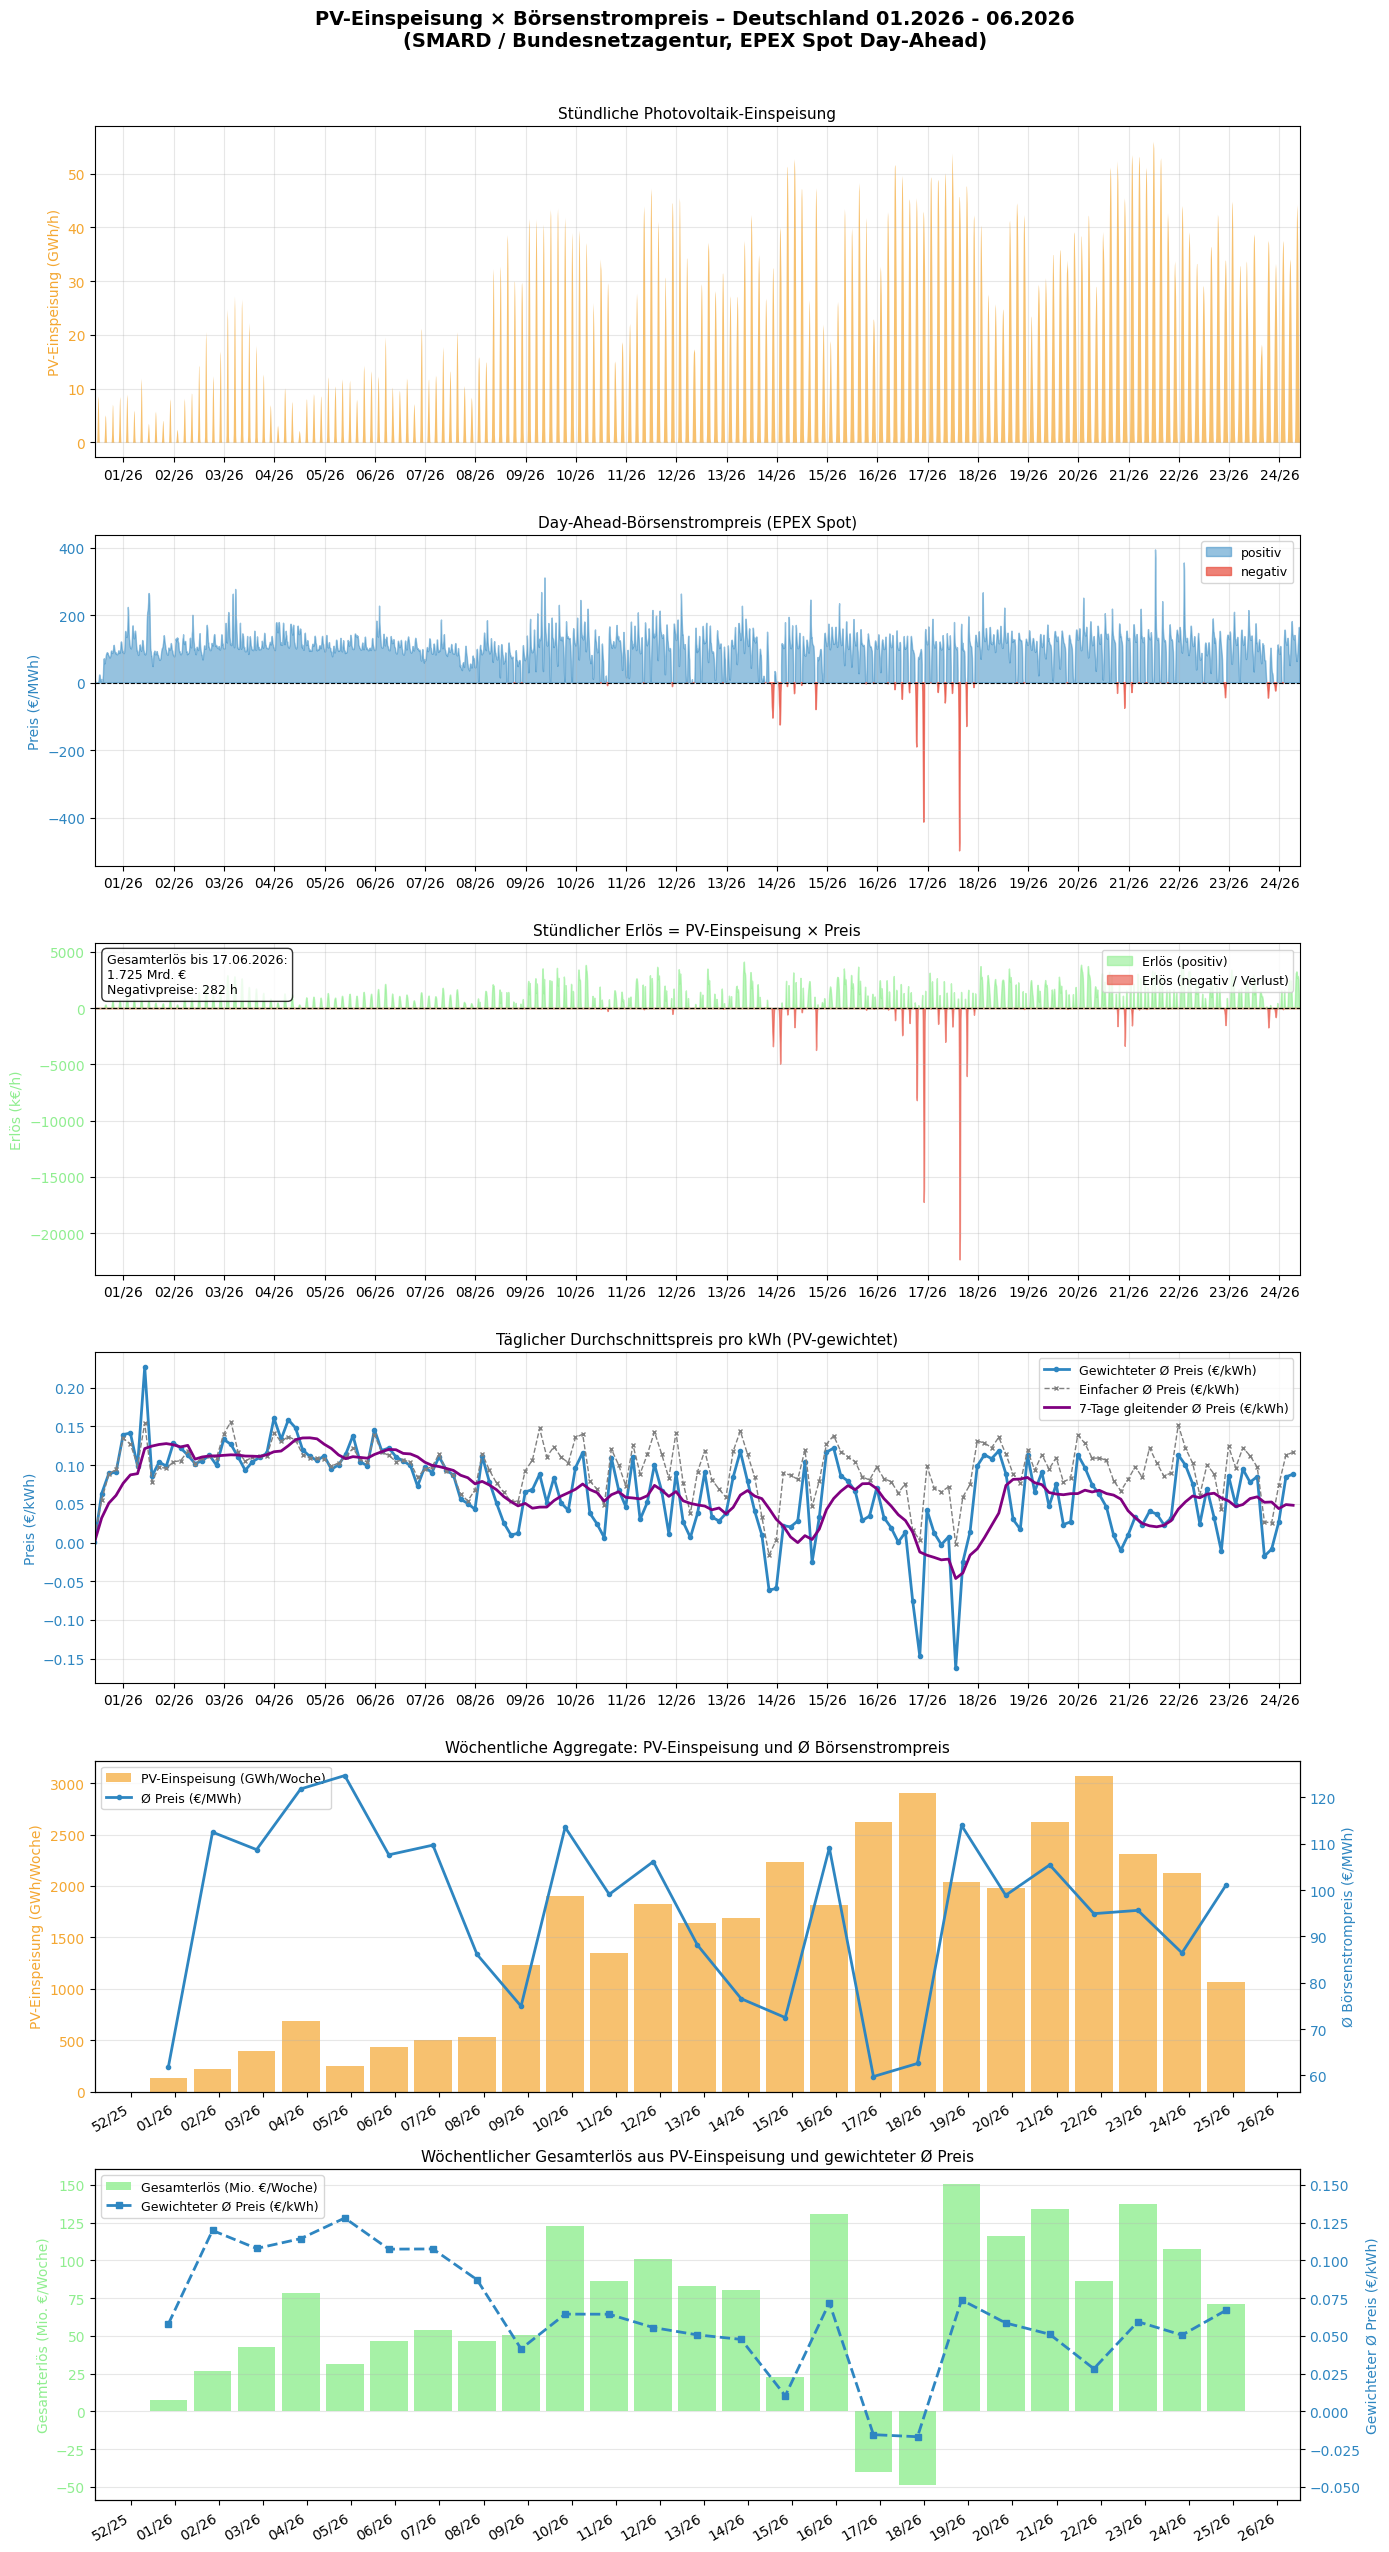

CSV-Daten gespeichert: smard_pv_preis_2026_01-2026_06.csv


In [16]:
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from datetime import datetime, timezone
import time

# ────────────────────────────────────
# Konfiguration
# ────────────────────────────────────

# Standardwerte (aktueller Monat/Jahr)
default_today = datetime.now()
default_year = default_today.year
default_month = default_today.month

# --- Konfigurierbare Parameter ---
# Setze den gewünschten Startzeitraum für die Datenabfrage.
# Für ein ganzes Jahr: START_JAHR = 2023, START_MONAT = None
# Für einen spezifischen Monat: START_JAHR = 2023, START_MONAT = 6 (Juni)
# Wenn END_JAHR und END_MONAT gesetzt sind, wird ein Zeitraum abgerufen.
# (Hinweis: Die SMARD API liefert maximal 2 Jahre am Stück für Day-Ahead-Preise)
START_JAHR = default_year    # Z.B. 2023, 2024. Standard: aktuelles Jahr
START_MONAT = 1              # Z.B. 1 (Januar) bis 12 (Dezember). Standard: aktueller Monat. Setze auf None für ganzes Jahr.
END_JAHR = None              # Optional: Endjahr für Zeitraum. Standard: Gleich START_JAHR
END_MONAT = 6             # Optional: Endmonat für Zeitraum. Standard: Gleich START_MONAT
# -----------------------------------

REGION = "DE"
RESOLUTION = "hour"          # stündliche Daten

FILTER_PV = 4068          # Stromerzeugung Photovoltaik
FILTER_PREIS = 4169          # Day-Ahead-Marktpreis (EPEX Spot)

BASE_URL = "https://www.smard.de/app/chart_data"

# ────────────────────────────────────
# Hilfsfunktionen
# ────────────────────────────────────

def get_index(filter_id: int) -> list[int]:
    """Gibt alle verfügbaren Wochen-Timestamps für einen Filter zurück."""
    url = f"{BASE_URL}/{filter_id}/{REGION}/index_{RESOLUTION}.json"
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    return r.json()["timestamps"]


def get_timeseries(filter_id: int, timestamp: int) -> list:
    """Lädt eine Woche Zeitreihendaten ab dem gegebenen Timestamp."""
    url = (f"{BASE_URL}/{filter_id}/{REGION}/"
           f"{filter_id}_{REGION}_{RESOLUTION}_{timestamp}.json")
    r = requests.get(url, timeout=30)
    r.raise_for_status()
    return r.json()["series"]


def fetch_period(filter_id: int, label: str, start_year: int, start_month: int = None, end_year: int = None, end_month: int = None) -> pd.Series:
    """
    Kombiniert alle Wochen-Chunks eines Jahres/Monats/Zeitraum zu einer stündlichen pd.Series.
    Timestamps in der API sind Unix-Millisekunden (UTC).
    """
    print(f"  Lade Index für {label} ...")
    all_ts = get_index(filter_id)

    # Bestimme den genauen Start- und Endzeitpunkt für die Filterung
    if start_month is None:
        # Ganzer Jahreszeitraum
        start_dt = datetime(start_year, 1, 1, tzinfo=timezone.utc)
        end_dt = datetime(end_year + 1 if end_year else start_year + 1, 1, 1, tzinfo=timezone.utc)
        period_label = f"{start_year}-{end_year}" if end_year and end_year != start_year else str(start_year)
    elif end_year and end_month:
        # Spezifischer Zeitraum (Monate)
        start_dt = datetime(start_year, start_month, 1, tzinfo=timezone.utc)
        if end_month == 12:
            end_dt = datetime(end_year + 1, 1, 1, tzinfo=timezone.utc)
        else:
            end_dt = datetime(end_year, end_month + 1, 1, tzinfo=timezone.utc)
        period_label = f"{start_month:02d}.{start_year}-{end_month:02d}.{end_year}"
    else:
        # Einzelner Monat
        start_dt = datetime(start_year, start_month, 1, tzinfo=timezone.utc)
        if start_month == 12:
            end_dt = datetime(start_year + 1, 1, 1, tzinfo=timezone.utc)
        else:
            end_dt = datetime(start_year, start_month + 1, 1, tzinfo=timezone.utc)
        period_label = f"{start_month:02d}.{start_year}"

    start_period_ts_ms = int(start_dt.timestamp() * 1000)
    end_period_ts_ms = int(end_dt.timestamp() * 1000)

    # Chunks: alle Chunks, die Daten für den Zielzeitraum enthalten könnten
    # Wir berücksichtigen Chunks, die bis zu einer Woche vor dem Zielzeitraum beginnen
    relevant = [t for t in all_ts if t >= start_period_ts_ms - 7 * 24 * 3600 * 1000]

    records = []
    total = len(relevant)
    for i, ts in enumerate(relevant):
        print(f"    Chunk {i+1}/{total} ({datetime.fromtimestamp(ts/1000, tz=timezone.utc).date()}) ...",
              end="\r")
        try:
            series = get_timeseries(filter_id, ts)
            for entry in series:
                t_ms, value = entry
                if value is not None and start_period_ts_ms <= t_ms < end_period_ts_ms:
                    records.append((t_ms, value))
        except Exception as e:
            print(f"\n    Warnung: Chunk {ts} übersprungen ({e})")
        time.sleep(0.15)   # API freundlich anfragen

    print(f"\n  {len(records)} Stundenwerte für {label} geladen.")
    if not records:
        raise ValueError(f"Keine Daten für Filter {filter_id} im Zeitraum {period_label} gefunden.")

    idx = pd.to_datetime([r[0] for r in records], unit="ms", utc=True).tz_convert("Europe/Berlin")
    vals = [r[1] for r in records]
    s = pd.Series(vals, index=idx, name=label)
    s = s[~s.index.duplicated()].sort_index()
    return s


# ────────────────────────────────────
# Daten laden
# ────────────────────────────────────

# Bestimme den tatsächlichen Zeitraum für den Download
current_start_year = START_JAHR
current_start_month = START_MONAT
current_end_year = END_JAHR if END_JAHR else START_JAHR
current_end_month = END_MONAT if END_MONAT else START_MONAT

if current_start_month is None:
    period_title = f"{current_start_year}"
    file_suffix = f"{current_start_year}"
elif current_end_year and current_end_month and (current_start_year != current_end_year or current_start_month != current_end_month):
    period_title = f"{current_start_month:02d}.{current_start_year} - {current_end_month:02d}.{current_end_year}"
    file_suffix = f"{current_start_year}_{current_start_month:02d}-{current_end_year}_{current_end_month:02d}"
elif current_end_year and current_end_month:
    period_title = f"{current_start_month:02d}.{current_start_year} - {current_end_month:02d}.{current_end_year}"
    file_suffix = f"{current_start_year}_{current_start_month:02d}-{current_end_year}_{current_end_month:02d}"
else:
    period_title = f"{current_start_month:02d}.{current_start_year}"
    file_suffix = f"{current_start_year}_{current_start_month:02d}"


print(f"\n=== SMARD-Daten-Download für {period_title} ===\n")

pv = fetch_period(FILTER_PV, "PV-Einspeisung (MWh/h)", current_start_year, current_start_month, current_end_year, current_end_month)
preis = fetch_period(FILTER_PREIS, "Day-Ahead-Preis (€/MWh)", current_start_year, current_start_month, current_end_year, current_end_month)

# ────────────────────────────────────
# Berechnung Erlös
# ────────────────────────────────────

df = pd.DataFrame({"pv_mwh": pv, "preis_eur_mwh": preis}).dropna()

# Erlös in €/h  (PV in MWh, Preis in €/MWh → Produkt = €)
df["erloes_eur"] = df["pv_mwh"] * df["preis_eur_mwh"]

# Tägliche Aggregate für Übersicht
daily = df.resample("D").agg(
    mean_price_eur_mwh=("preis_eur_mwh", "mean"),
    weighted_avg_price_eur_mwh=("erloes_eur", lambda x: x.sum() / df.loc[x.index, "pv_mwh"].sum() if df.loc[x.index, "pv_mwh"].sum() > 0 else 0)
)

daily["mean_price_eur_kwh"] = daily["mean_price_eur_mwh"] / 1000
daily["weighted_avg_price_eur_kwh"] = daily["weighted_avg_price_eur_mwh"] / 1000
# Calculate 7-day rolling average
daily['rolling_avg_price_eur_kwh'] = daily['weighted_avg_price_eur_kwh'].rolling(window=7, min_periods=1).mean()

# Wöchentliche Aggregate für Übersicht
weekly = df.resample("W").agg(
    pv_gwh     =("pv_mwh",       lambda x: x.sum() / 1000),
    preis_mean =("preis_eur_mwh", "mean"),
    erloes_meur=("erloes_eur",    lambda x: x.sum() / 1_000_000),
    sum_erloes_eur=("erloes_eur", "sum"),  # Temporary sum for weighted average
    sum_pv_mwh=("pv_mwh", "sum")          # Temporary sum for weighted average
)
weekly["weighted_avg_price_eur_mwh"] = weekly.apply(
    lambda row: row["sum_erloes_eur"] / row["sum_pv_mwh"] if row["sum_pv_mwh"] > 0 else 0,
    axis=1
)
weekly["weighted_avg_price_eur_kwh"] = weekly["weighted_avg_price_eur_mwh"] / 1000
# Drop the intermediate sum columns
weekly = weekly.drop(columns=["sum_erloes_eur", "sum_pv_mwh"])

# ────────────────────────────────────
# Zusammenfassung
# ────────────────────────────────────

print("\n=== Zusammenfassung ===")
print(f"Zeitraum:              {df.index[0].date()} – {df.index[-1].date()}")
print(f"Datenpunkte:           {len(df):,} Stunden")
print(f"PV-Einspeisung gesamt: {df['pv_mwh'].sum()/1e6:.2f} TWh")
print(f"Ø Börsenstrompreis:    {df['preis_eur_mwh'].mean():.1f} €/MWh")
print(f"Negativpreise:         {(df['preis_eur_mwh'] < 0).sum()} Stunden")
print(f"Erlös gesamt:          {df['erloes_eur'].sum()/1e9:.3f} Mrd. €")

# ────────────────────────────────────
# Grafik
# ────────────────────────────────────

fig, axes = plt.subplots(6, 1, figsize=(14, 26), sharex=False) # Increased rows for new plot
fig.suptitle(f"PV-Einspeisung × Börsenstrompreis – Deutschland {period_title}\n"
             f"(SMARD / Bundesnetzagentur, EPEX Spot Day-Ahead)",
             fontsize=14, fontweight="bold", y=0.98)

farbe_pv = "#F4A732"   # Solar-Orange
farbe_preis = "#2E86C1"   # Blau
farbe_erloes = "#90EE90"   # Grün
farbe_neg = "#E74C3C"   # Rot für Negativpreise

# ── Panel 1: Stündliche PV-Einspeisung (komplett) ──
ax1 = axes[0]
ax1.fill_between(df.index, df["pv_mwh"] / 1000, color=farbe_pv, alpha=0.7, linewidth=0)
ax1.set_ylabel("PV-Einspeisung (GWh/h)", color=farbe_pv, fontsize=10)
ax1.tick_params(axis="y", labelcolor=farbe_pv)
ax1.set_title("Stündliche Photovoltaik-Einspeisung", fontsize=11)
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%W/%y"))
ax1.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=1))
ax1.grid(True, alpha=0.3)
ax1.set_xlim(df.index[0], df.index[-1])

# ── Panel 2: Stündlicher Börsenstrompreis ──
ax2 = axes[1]
pos_mask = df["preis_eur_mwh"] >= 0
neg_mask = df["preis_eur_mwh"] < 0
ax2.fill_between(df.index, df["preis_eur_mwh"].where(pos_mask), 0,
                 color=farbe_preis, alpha=0.5, label="positiv")
ax2.fill_between(df.index, df["preis_eur_mwh"].where(neg_mask), 0,
                 color=farbe_neg, alpha=0.7, label="negativ")
ax2.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax2.set_ylabel("Preis (€/MWh)", color=farbe_preis, fontsize=10)
ax2.tick_params(axis="y", labelcolor=farbe_preis)
ax2.set_title("Day-Ahead-Börsenstrompreis (EPEX Spot)", fontsize=11)
ax2.legend(loc="upper right", fontsize=9)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%W/%y"))
ax2.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=1))
ax2.grid(True, alpha=0.3)
ax2.set_xlim(df.index[0], df.index[-1])

# ── Panel 3: Stündlicher Erlös ──
ax3 = axes[2]
erloes_pos = df["erloes_eur"].clip(lower=0)
erloes_neg = df["erloes_eur"].clip(upper=0)
ax3.fill_between(df.index, erloes_pos / 1000, color=farbe_erloes, alpha=0.6,
                 label="Erlös (positiv)")
ax3.fill_between(df.index, erloes_neg / 1000, color=farbe_neg, alpha=0.6,
                 label="Erlös (negativ / Verlust)")
ax3.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax3.set_ylabel("Erlös (k€/h)", color=farbe_erloes, fontsize=10)
ax3.tick_params(axis="y", labelcolor=farbe_erloes)
ax3.set_title("Stündlicher Erlös = PV-Einspeisung × Preis", fontsize=11)
ax3.legend(loc="upper right", fontsize=9)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%W/%y"))
ax3.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=1))
ax3.grid(True, alpha=0.3)
ax3.set_xlim(df.index[0], df.index[-1])

# ── Panel 4: Täglicher Durchschnittspreis pro kWh ──
ax4 = axes[3]
ax4.plot(daily.index, daily["weighted_avg_price_eur_kwh"], color=farbe_preis, linewidth=2, marker="o", markersize=3, label="Gewichteter Ø Preis (€/kWh)")
ax4.plot(daily.index, daily["mean_price_eur_kwh"], color='gray', linestyle='--', linewidth=1, marker='x', markersize=3, label="Einfacher Ø Preis (€/kWh)")
ax4.plot(daily.index, daily['rolling_avg_price_eur_kwh'], color='purple', linestyle='-', linewidth=2, label='7-Tage gleitender Ø Preis (€/kWh)') # Added rolling average plot
ax4.set_ylabel("Preis (€/kWh)", color=farbe_preis, fontsize=10)
ax4.tick_params(axis="y", labelcolor=farbe_preis)
ax4.set_title("Täglicher Durchschnittspreis pro kWh (PV-gewichtet)", fontsize=11)
ax4.legend(loc="upper right", fontsize=9)
ax4.xaxis.set_major_formatter(mdates.DateFormatter("%W/%y"))
ax4.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=1))
ax4.grid(True, alpha=0.3)
ax4.set_xlim(df.index[0], df.index[-1])

# ── Panel 5: Wöchentliche Aggregate: PV-Einspeisung und Ø Börsenstrompreis ──
ax5 = axes[4]
ax5b = ax5.twinx()

bars = ax5.bar(weekly.index, weekly["pv_gwh"], width=6,
               color=farbe_pv, alpha=0.7, label="PV-Einspeisung (GWh/Woche)")
ax5b.plot(weekly.index, weekly["preis_mean"], color=farbe_preis,
          linewidth=2, marker="o", markersize=3, label="Ø Preis (€/MWh)")

ax5.set_ylabel("PV-Einspeisung (GWh/Woche)", color=farbe_pv, fontsize=10)
ax5b.set_ylabel("Ø Börsenstrompreis (€/MWh)", color=farbe_preis, fontsize=10)
ax5.tick_params(axis="y", labelcolor=farbe_pv)
ax5b.tick_params(axis="y", labelcolor=farbe_preis)
ax5.set_title("Wöchentliche Aggregate: PV-Einspeisung und Ø Börsenstrompreis", fontsize=11)
ax5.xaxis.set_major_formatter(mdates.DateFormatter("%W/%y"))
ax5.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=1))
plt.setp(ax5.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax5.grid(True, alpha=0.3, axis="y")

# Legende kombinieren
lines_ax5, labels_ax5 = ax5.get_legend_handles_labels()
lines_ax5b, labels_ax5b = ax5b.get_legend_handles_labels()
ax5.legend(lines_ax5 + lines_ax5b, labels_ax5 + labels_ax5b, loc="upper left", fontsize=9)

# ── Panel 6: Wöchentlicher Gesamterlös und gewichteter Durchschnittspreis ──
ax6 = axes[5]
ax6b = ax6.twinx() # Create a twin axis for the price

ax6.bar(weekly.index, weekly["erloes_meur"], width=6, color=farbe_erloes, alpha=0.8, label="Gesamterlös (Mio. €/Woche)")
ax6b.plot(weekly.index, weekly["weighted_avg_price_eur_kwh"], color=farbe_preis,
          linewidth=2, marker="s", markersize=4, linestyle="--", label="Gewichteter Ø Preis (€/kWh)") # Plotting the new data

ax6.set_ylabel("Gesamterlös (Mio. €/Woche)", color=farbe_erloes, fontsize=10)
ax6b.set_ylabel("Gewichteter Ø Preis (€/kWh)", color=farbe_preis, fontsize=10) # New y-label
ax6.tick_params(axis="y", labelcolor=farbe_erloes)
ax6b.tick_params(axis="y", labelcolor=farbe_preis) # New tick params
ax6.set_title("Wöchentlicher Gesamterlös aus PV-Einspeisung und gewichteter Ø Preis", fontsize=11) # Updated title
ax6.xaxis.set_major_formatter(mdates.DateFormatter("%W/%y"))
ax6.xaxis.set_major_locator(mdates.WeekdayLocator(byweekday=0, interval=1))
plt.setp(ax6.xaxis.get_majorticklabels(), rotation=30, ha="right")
ax6.grid(True, alpha=0.3, axis="y")

# automatische Skalierung

ax6.relim()
ax6.autoscale_view()

ax6b.relim()
ax6b.autoscale_view()

# Untergrenze der rechten Achse mindestens -0.04 €/kWh

ymin, ymax = ax6.get_ylim()
yminb, ymaxb = ax6b.get_ylim()
yminb = ymin/1000
ymaxb = ymax/1000
ax6b.set_ylim(yminb, ymaxb)

# Nulllinien ausrichten
#align_yaxes_zero(ax6, ax6b)


# Legende für ax6 und ax6b kombinieren
lines_ax6, labels_ax6 = ax6.get_legend_handles_labels()
lines_ax6b, labels_ax6b = ax6b.get_legend_handles_labels()
ax6.legend(lines_ax6 + lines_ax6b, labels_ax6 + labels_ax6b, loc="upper left", fontsize=9)

# Annotationen
textstr = (f"Gesamterlös bis {df.index[-1].strftime('%d.%m.%Y')}:\n"
           f"{df['erloes_eur'].sum()/1e9:.3f} Mrd. €\n"
           f"Negativpreise: {(df['preis_eur_mwh'] < 0).sum()} h")
ax3.text(0.01, 0.97, textstr, transform=ax3.transAxes,
         fontsize=9, verticalalignment="top",
         bbox=dict(boxstyle="round,pad=0.4", facecolor="white", alpha=0.8))

plt.tight_layout(rect=[0, 0, 1, 0.97])

dateiname = f"smard_pv_preis_{file_suffix}.png"
plt.savefig(dateiname, dpi=150, bbox_inches="tight")
print(f"\nGrafik gespeichert: {dateiname}")
plt.show()

# ────────────────────────────────────
# CSV-Export (optional)
# ────────────────────────────────────
csv_name = f"smard_pv_preis_{file_suffix}.csv"
df.to_csv(csv_name, float_format="%.3f")
print(f"CSV-Daten gespeichert: {csv_name}")

In [14]:
ax6.get_ylim()


(np.float64(-58.87496886405499), np.float64(160.52131630015498))